# W tej części dodajemy zmienne techniczne i je analizujemy #

## 1. Import bibliotek ##

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('../'))
from src.data_loader import load_data
from src.features import add_momentum_features, add_mean_reversion_features, add_regime_features, add_volatility_features, build_feature_matrix

## 2. Załadowanie danych w użytecznej postacji i dodanie zmiennych technicznych ##

In [2]:
# 1. Wczytanie danych numerycznych
df = load_data('../data/processed/sp500_clean.csv')

# 2. STWORZENIE TARGETU: Przewidujemy log-zwrot za 5 dni (tydzień handlowy)
# shift(-5) przesuwa dane z przyszłości do obecnego wiersza
df['target_return'] = np.log(df['Price'].shift(-5) / df['Price'])

# Usuwamy ostatnie 5 wierszy, bo dla nich nie znamy jeszcze przyszłego zwrotu
df = df.dropna()

✅ Ustawiono indeks czasowy na kolumnie: Date


## 3. Ilościowa analiza danych ##

### Stworzenie ramki danych z tymi zmiennymi ktore nas interesuja ###

In [4]:
# Lista kolumn do usunięcia (bo są surowymi cenami lub powielają informację)
to_drop = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Change %', 'returns'] 

# Tworzymy czysty zbiór do analizy korelacji
# Zostawiamy wskaźniki techniczne i nasz Target
df = df.drop(columns=[col for col in to_drop if col in df.columns])
print(df.head())
print(df.columns)

              Price  target_return
Date                              
2023-01-04  3852.97       0.029824
2023-01-05  3808.10       0.044948
2023-01-06  3895.08       0.026353
2023-01-09  3892.09       0.025088
2023-01-10  3919.25       0.002449
Index(['Price', 'target_return'], dtype='object')


### Dodanie zmiennej opóźnionej ###

In [57]:
df['lag_return'] = df['target_return'].shift(5)

### Dodanie zmiennych mierzących pęd i ich analiza ###

In [7]:
# Dodanie zmiennych od pędu
df_momentum = add_momentum_features(df, window = 10)
df_momentum.dropna(inplace = True)
df_momentum.head()

,Price,target_return,mom_RSI,mom_ROC
Date,,,,
2023-01-19,3898.85,0.040607,56.706034,0.011908
2023-01-20,3972.61,0.024357,72.172952,0.043200
2023-01-23,4019.81,-0.000508,68.830581,0.032022
2023-01-24,4016.95,0.014740,68.857609,0.032080
2023-01-25,4016.22,0.025320,65.916029,0.024742


Szereg czasowy zmienna vs target

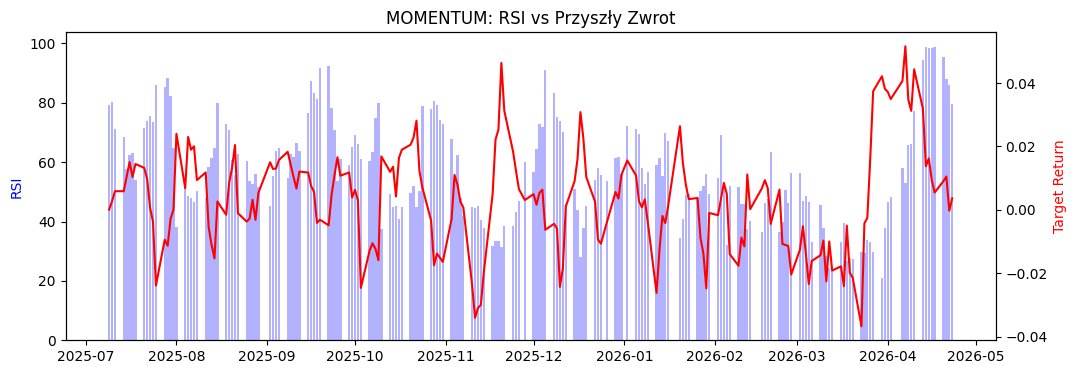

In [17]:
# --- WYKRES SZEREGU CZASOWEGO (Ostatnie 100 dni) ---
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(df_momentum.index[-200:], df_momentum['mom_RSI'].tail(200), color='blue', label='RSI', alpha = 0.3)
ax2.plot(df_momentum.index[-200:], df_momentum['target_return'].tail(200), color='red', label='Next Day Return')

ax1.set_ylabel('RSI', color='blue')
ax2.set_ylabel('Target Return', color='red')
plt.title('MOMENTUM: RSI vs Przyszły Zwrot')
plt.show()

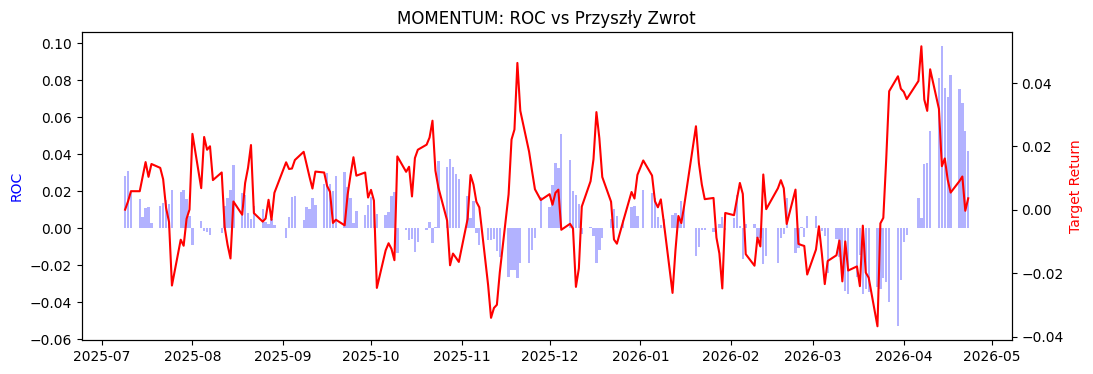

In [18]:
# --- WYKRES SZEREGU CZASOWEGO (Ostatnie 200 dni) ---
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(df_momentum.index[-200:], df_momentum['mom_ROC'].tail(200), color='blue', label='RSI', alpha = 0.3)
ax2.plot(df_momentum.index[-200:], df_momentum['target_return'].tail(200), color='red', label='Next Day Return')

ax1.set_ylabel('ROC', color='blue')
ax2.set_ylabel('Target Return', color='red')
plt.title('MOMENTUM: ROC vs Przyszły Zwrot')
plt.show()

In [19]:
# --- KORELACJA ---
print("Korelacja Rodziny Momentum z Targetem:")
print(df_momentum[['mom_RSI', 'mom_ROC', 'target_return']].corr()['target_return'])

Korelacja Rodziny Momentum z Targetem:
mom_RSI         -0.040025
mom_ROC         -0.032510
target_return    1.000000
Name: target_return, dtype: float64


### Dodanie zmiennych mean-reversion ###

In [ ]:
# Dodanie zmiennych od powrotu do sredniej
df_mr = add_mean_reversion_features(df)
df_mr.dropna(inplace = True)
df_mr.head()

,Price,target_return,mr_Zscore,mr_DistSMA200
Date,,,,
2023-10-19,4278.00,-0.033459,-0.788582,0.011043
2023-10-20,4224.16,-0.025606,-1.769698,-0.002119
2023-10-23,4217.04,-0.011980,-1.669331,-0.004282
2023-10-24,4247.68,-0.012766,-1.010390,0.002535
2023-10-25,4186.77,0.012129,-1.903779,-0.012184


Szereg czasowy zmienna vs target

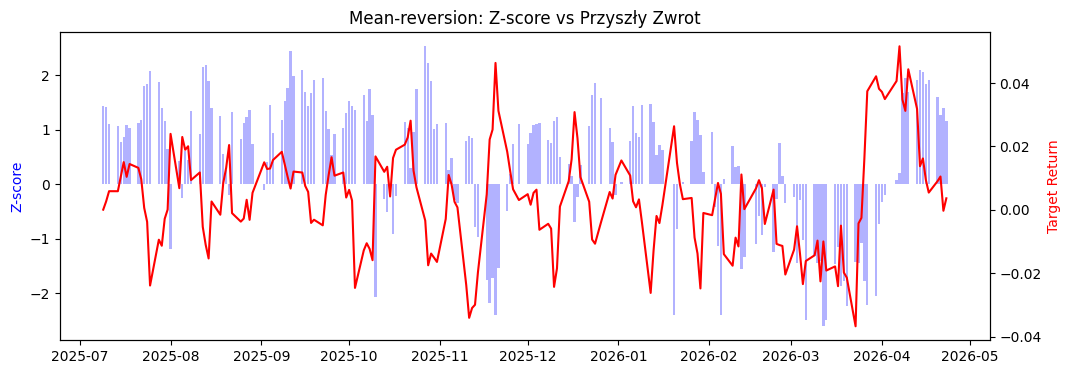

In [ ]:
# --- WYKRES SZEREGU CZASOWEGO (Ostatnie 200 dni) ---
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(df_mr.index[-200:], df_mr['mr_Zscore'].tail(200), color='blue', label='Z-score', alpha = 0.3)
ax2.plot(df_mr.index[-200:], df_mr['target_return'].tail(200), color='red', label='Next Day Return')

ax1.set_ylabel('Z-score', color='blue')
ax2.set_ylabel('Target Return', color='red')
plt.title('Mean-reversion: Z-score vs Przyszły Zwrot')
plt.show()

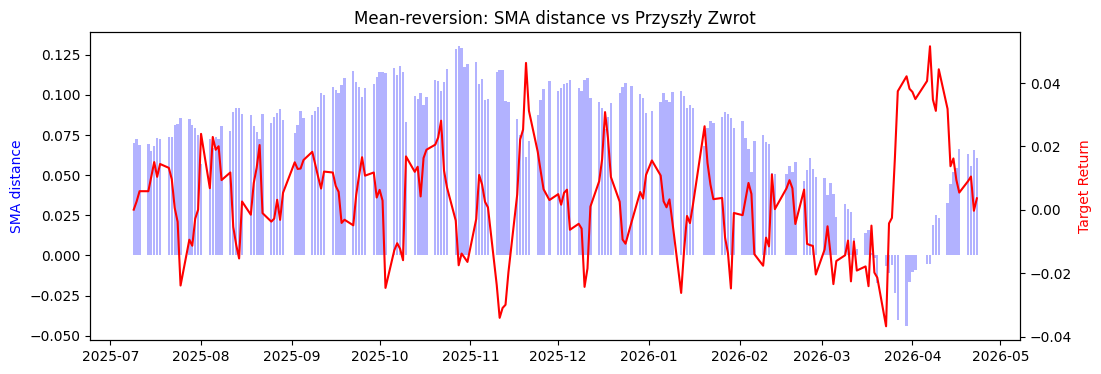

In [22]:
# --- WYKRES SZEREGU CZASOWEGO (Ostatnie 100 dni) ---
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(df_mr.index[-200:], df_mr['mr_DistSMA200'].tail(200), color='blue', label='SMA distance', alpha = 0.3)
ax2.plot(df_mr.index[-200:], df_mr['target_return'].tail(200), color='red', label='Next Day Return')

ax1.set_ylabel('SMA distance', color='blue')
ax2.set_ylabel('Target Return', color='red')
plt.title('Mean-reversion: SMA distance vs Przyszły Zwrot')
plt.show()

In [23]:
# --- KORELACJA ---
print("Korelacja Rodziny Mean-reversion z Targetem:")
print(df_mr[['mr_Zscore', 'mr_DistSMA200', 'target_return']].corr()['target_return'])

Korelacja Rodziny Mean-reversion z Targetem:
mr_Zscore       -0.066724
mr_DistSMA200   -0.186943
target_return    1.000000
Name: target_return, dtype: float64


### Dodanie zmiennych mierzacych zmiennosc ###


In [24]:
# Dodanie zmiennych od zmiennosci
df_vol = add_volatility_features(df)
df_vol.dropna(inplace = True)
df_vol.head()

,Price,target_return,vol_RollingStd,vol_Range
Date,,,,
2023-01-25,4016.22,0.025320,0.174118,211.71
2023-01-26,4060.43,0.028965,0.163296,168.34
2023-01-27,4070.56,0.016065,0.141102,178.47
2023-01-30,4017.77,0.022959,0.156498,171.71
2023-01-31,4076.60,0.021213,0.164023,177.75


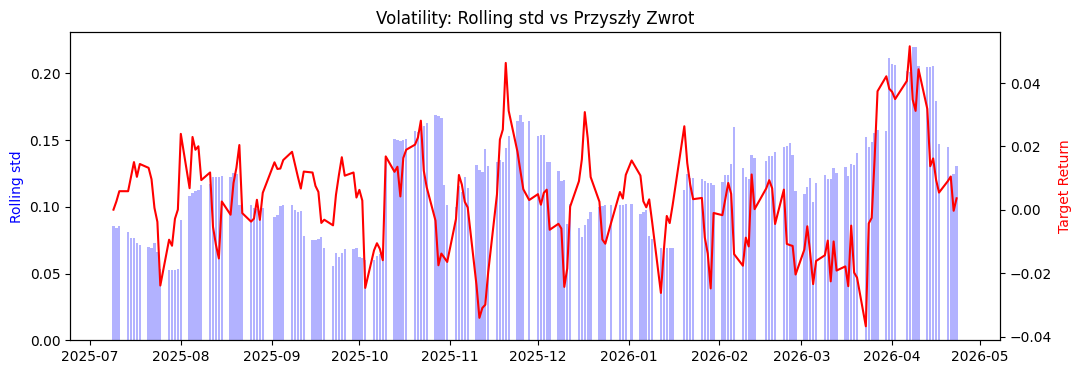

In [25]:
# --- WYKRES SZEREGU CZASOWEGO (Ostatnie 200 dni) ---
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(df_vol.index[-200:], df_vol['vol_RollingStd'].tail(200), color='blue', label='Rolling std', alpha = 0.3)
ax2.plot(df_vol.index[-200:], df_vol['target_return'].tail(200), color='red', label='Next Day Return')

ax1.set_ylabel('Rolling std', color='blue')
ax2.set_ylabel('Target Return', color='red')
plt.title('Volatility: Rolling std vs Przyszły Zwrot')
plt.show()

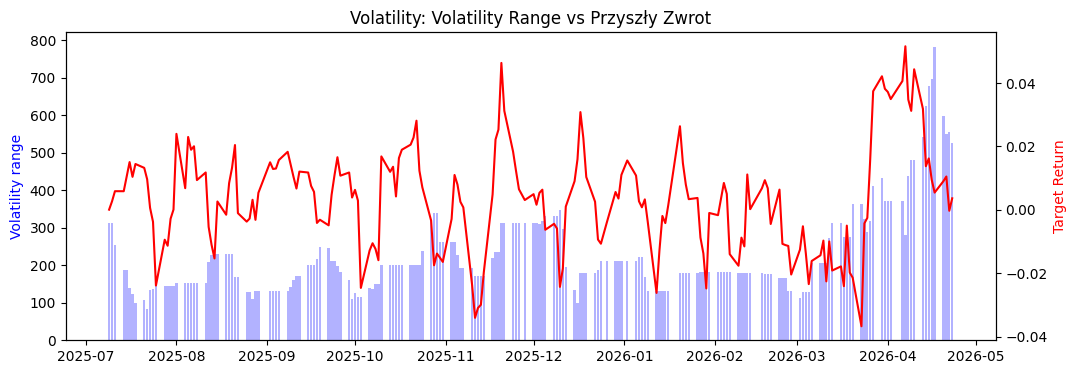

In [26]:
# --- WYKRES SZEREGU CZASOWEGO (Ostatnie 200 dni) ---
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(df_vol.index[-200:], df_vol['vol_Range'].tail(200), color='blue', label='Volatility Range', alpha = 0.3)
ax2.plot(df_vol.index[-200:], df_vol['target_return'].tail(200), color='red', label='Next Day Return')

ax1.set_ylabel('Volatility range', color='blue')
ax2.set_ylabel('Target Return', color='red')
plt.title('Volatility: Volatility Range vs Przyszły Zwrot')
plt.show()

In [27]:
# --- KORELACJA ---
print("Korelacja Rodziny Volatility z Targetem:")
print(df_vol[['vol_RollingStd', 'vol_Range', 'target_return']].corr()['target_return'])

Korelacja Rodziny Volatility z Targetem:
vol_RollingStd    0.161697
vol_Range         0.155262
target_return     1.000000
Name: target_return, dtype: float64


### Zmienne badające reżimy ###

In [32]:
# Dodanie zmiennych od reżimów
df_reg = add_regime_features(df)
df_reg.dropna(inplace = True)
df_reg.head()

,Price,target_return,reg_IsBull
Date,,,
2023-01-04,3852.97,0.029824,0
2023-01-05,3808.10,0.044948,0
2023-01-06,3895.08,0.026353,0
2023-01-09,3892.09,0.025088,0
2023-01-10,3919.25,0.002449,0


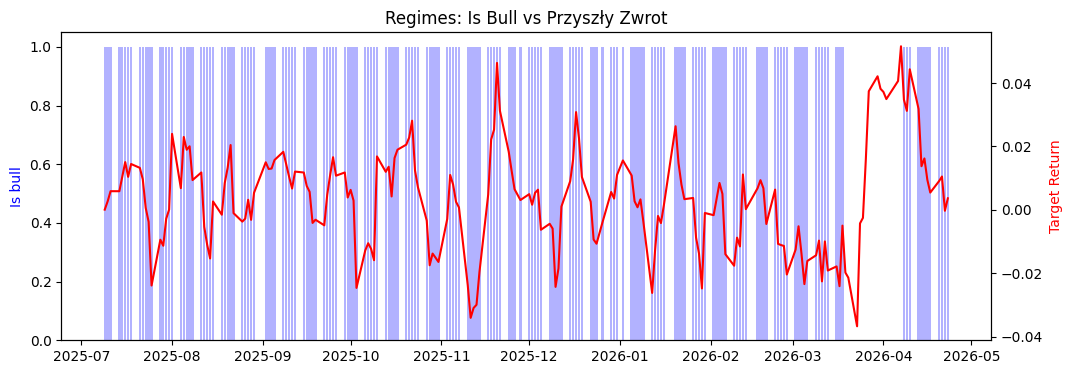

In [33]:
# --- WYKRES SZEREGU CZASOWEGO (Ostatnie 200 dni) ---
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(df_reg.index[-200:], df_reg['reg_IsBull'].tail(200), color='blue', label='Is Bull', alpha = 0.3)
ax2.plot(df_vol.index[-200:], df_vol['target_return'].tail(200), color='red', label='Next Day Return')

ax1.set_ylabel('Is bull', color='blue')
ax2.set_ylabel('Target Return', color='red')
plt.title('Regimes: Is Bull vs Przyszły Zwrot')
plt.show()

In [34]:
# --- KORELACJA ---
print("Korelacja Rodziny Regimes z Targetem:")
print(df_reg[['reg_IsBull', 'target_return']].corr()['target_return'])

Korelacja Rodziny Regimes z Targetem:
reg_IsBull      -0.026918
target_return    1.000000
Name: target_return, dtype: float64


## Finalne zmienne brane pod uwage ##

In [58]:
# 1. Wybieramy listę "finalistów" na podstawie wcześniejszych analiz
df_final = build_feature_matrix(df)
selected_features = ['mom_RSI', 'mr_DistSMA200', 'vol_RollingStd', 'reg_IsBull', 'lag_return']
all_cols = selected_features + ['target_return']

df_final.head()

,Price,target_return,lag_return,mom_RSI,mom_ROC,mr_Zscore,mr_DistSMA200,vol_RollingStd,vol_Range,reg_IsBull,target_next_return
Date,,,,,,,,,,,
2023-10-19,4278.00,-0.033459,-0.016601,48.770040,-0.002344,-0.788582,0.011043,0.132895,147.50,1,-0.012665
2023-10-20,4224.16,-0.025606,-0.024234,43.049454,-0.014978,-1.769698,-0.002119,0.143047,152.79,0,-0.001687
2023-10-23,4217.04,-0.011980,-0.036460,48.487434,-0.002934,-1.669331,-0.004282,0.130799,159.91,0,0.007239
2023-10-24,4247.68,-0.012766,-0.029122,48.023711,-0.003769,-1.010390,0.002535,0.129815,159.91,1,-0.014443
2023-10-25,4186.77,0.012129,-0.030075,42.269224,-0.016772,-1.903779,-0.012184,0.143131,190.18,0,-0.011903


In [59]:
# 2. Stwórz czystą ramkę tylko z wybranymi danymi
df_final = df_final[all_cols]

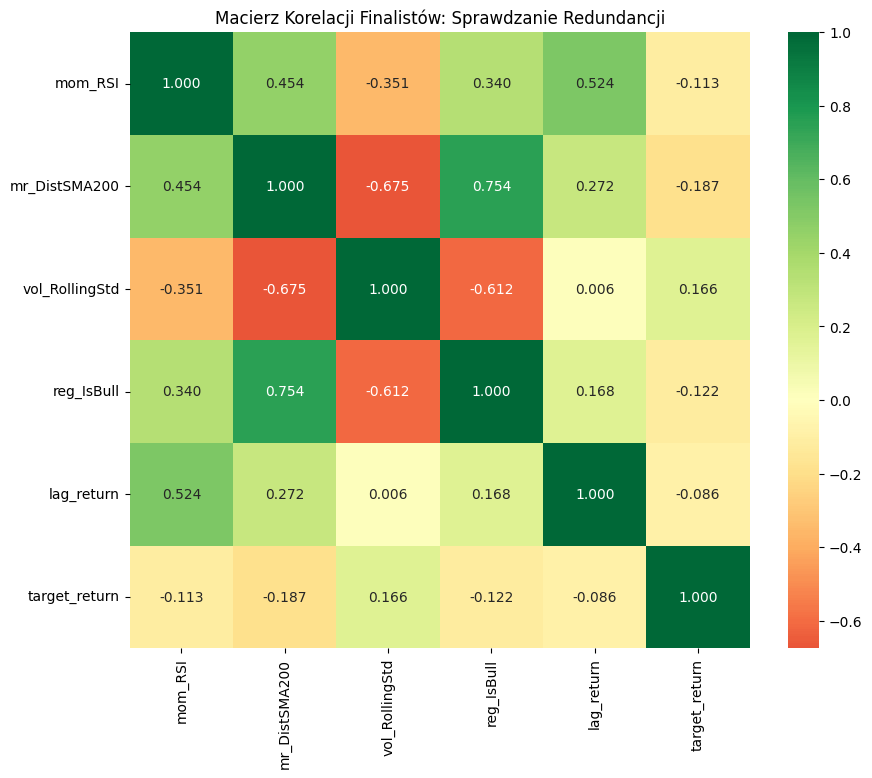

Macierz korelacji zmiennych
                 mom_RSI  mr_DistSMA200  vol_RollingStd  reg_IsBull  \
mom_RSI         1.000000       0.454429       -0.350846    0.339877   
mr_DistSMA200   0.454429       1.000000       -0.675050    0.754295   
vol_RollingStd -0.350846      -0.675050        1.000000   -0.611613   
reg_IsBull      0.339877       0.754295       -0.611613    1.000000   
lag_return      0.524093       0.271709        0.006483    0.167690   
target_return  -0.112799      -0.186964        0.165687   -0.122460   

                lag_return  target_return  
mom_RSI           0.524093      -0.112799  
mr_DistSMA200     0.271709      -0.186964  
vol_RollingStd    0.006483       0.165687  
reg_IsBull        0.167690      -0.122460  
lag_return        1.000000      -0.086360  
target_return    -0.086360       1.000000  


In [60]:
# 3. Macierz korelacji wzajemnej
plt.figure(figsize=(10, 8))
correlation_matrix = df_final.corr()

# Rysujemy heatmapę z adnotacjami
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".3f")
plt.title('Macierz Korelacji Finalistów: Sprawdzanie Redundancji')
plt.show()

print('Macierz korelacji zmiennych')
print(correlation_matrix)

In [48]:
# 4. Sprawdzenie statystyczne (Information Coefficient)
print("Korelacja z Targetem (ranking siły):")
print(correlation_matrix['target_return'].sort_values(ascending=False))

Korelacja z Targetem (ranking siły):
target_return     1.000000
vol_RollingStd    0.165687
mom_RSI          -0.112799
reg_IsBull       -0.122460
mr_DistSMA200    -0.186964
Name: target_return, dtype: float64


## Zapisanie pliku do csv z ostateczna kombinacja zmiennych ##

In [63]:
# Finalna lista cech po eliminacji redundancji
final_selection = [
    'mom_RSI', 
    'mr_DistSMA200', 
    'vol_RollingStd', 
    'lag_return'
]

# Tworzymy ostateczny DataFrame
df_ready = df_final[final_selection + ['target_return']].dropna()

# Zapis do folderu processed
df_ready.to_csv('../data/processed/sp500_ready.csv')

print(f"🚀 Gotowe! Zredukowano multikolinearność. Plik zawiera {len(df_ready)} wierszy.")

🚀 Gotowe! Zredukowano multikolinearność. Plik zawiera 628 wierszy.
